In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
import torch.nn.functional as F

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [ ]:
train_dir = "/content/drive/MyDrive/bottle/train"
test_dir = "/content/drive/MyDrive/bottle"


In [ ]:
weights = Wide_ResNet50_2_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

In [ ]:
train_dataset = ImageFolder(root = train_dir, transform = preprocess)
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = False)

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset
import torch
import glob

class MVTecTestDataset(Dataset):
    def __init__(self, root, transform, mask_transform=None):
        self.root = root
        self.transform = transform
        self.mask_transform = mask_transform

        self.samples = []

        test_dir = os.path.join(root, "test")
        gt_dir = os.path.join(root, "ground_truth")

        classes = sorted(os.listdir(test_dir))

        for cls in classes:
            img_paths = glob.glob(os.path.join(test_dir, cls, "*.png"))

            for img_path in img_paths:
                if cls == "good":
                    self.samples.append((img_path, 0, None))
                else:
                    mask_name = os.path.basename(img_path).replace(".png", "_mask.png")
                    mask_path = os.path.join(gt_dir, cls, mask_name)
                    self.samples.append((img_path, 1, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, mask_path = self.samples[idx]

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        if label == 0:
            mask = torch.zeros((1, image.shape[1], image.shape[2]))
        else:
            mask = Image.open(mask_path).convert("L")
            if self.mask_transform:
                mask = self.mask_transform(mask)
                mask = (mask > 0.5).float()

        return image, label, mask

In [ ]:
mask_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

In [ ]:
weights = Wide_ResNet50_2_Weights.IMAGENET1K_V1
model = wide_resnet50_2(weights)
preprocess = weights.transforms()
model = model.to(device)

model.eval()
for params in model.parameters():
  params.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:00<00:00, 155MB/s]


In [ ]:
test_dataset = MVTecTestDataset(test_dir, preprocess, mask_transform)
test_dataloader = DataLoader(test_dataset, batch_size = 16, shuffle = False)

In [ ]:
feature_maps = []

def hook_fn(module, input, output):
  feature_maps.append(output)

model.layer2[-1].register_forward_hook(hook_fn)
model.layer3[-1].register_forward_hook(hook_fn)

In [ ]:
all_embeddings = []

model.eval()

with torch.no_grad():
    for images, _ in train_loader:

        images = images.to(device)

        feature_maps.clear()

        _ = model(images)

        f2, f3 = feature_maps

        f3 = F.interpolate(f3, size = f2.shape[-2:], mode = 'bilinear', align_corners = False)
        f = torch.cat([f2,f3], dim = 1)

        B, C, H, W = f.shape
        patch_embeddings = f.permute(0, 2, 3, 1).reshape(-1, C)

        all_embeddings.append(patch_embeddings.cpu())
memory_bank = torch.cat(all_embeddings, dim = 0)

In [ ]:
f2.shape

torch.Size([1, 512, 28, 28])

In [ ]:
f3.shape

torch.Size([1, 1024, 28, 28])

In [ ]:
memory_bank.shape

torch.Size([163856, 1536])

In [ ]:
memory_bank.mean()

tensor(0.0682)

In [ ]:
memory_bank.std()

tensor(0.1290)

In [ ]:
from sklearn.random_projection import SparseRandomProjection

projection = SparseRandomProjection(n_components = 128)
mem_bank = projection.fit_transform(memory_bank)

mem_bank.shape

(163856, 128)

In [ ]:
import torch
import numpy as np

def greedy_coreset_sampling(embeddings, sampling_ratio=0.01):

    embeddings = torch.tensor(embeddings)

    N = embeddings.shape[0]
    sample_size = int(N * sampling_ratio)

    selected_indices = []

    # randomly choose first point
    first_idx = torch.randint(0, N, (1,))
    selected_indices.append(first_idx.item())

    distances = torch.cdist(
        embeddings[first_idx].unsqueeze(0),
        embeddings
    ).squeeze()

    for _ in range(sample_size - 1):

        farthest_idx = torch.argmax(distances)
        selected_indices.append(farthest_idx.item())

        new_dist = torch.cdist(
            embeddings[farthest_idx].unsqueeze(0),
            embeddings
        ).squeeze()

        distances = torch.minimum(distances, new_dist)

    return selected_indices

In [ ]:
indices = greedy_coreset_sampling(mem_bank, 0.01)

memory_bank_coreset = mem_bank[indices]

In [ ]:
memory_bank_coreset.shape

(1638, 128)

In [ ]:
N = 150000
sample_size = int(N * 0.01)

selected_indices = []

first_idx = torch.randint(0, N, (1,))

selected_indices.append(first_idx.item())



In [ ]:
first_idx

tensor([122253])

In [ ]:
model.eval()

test_embeddings = []

with torch.no_grad():
    for images, labels, masks in test_dataloader:

      images = images.to(device)

      feature_maps.clear()

      _ = model(images)

      f2, f3 = feature_maps

      f3 = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)

      f = torch.cat([f2, f3], dim=1)

      B, C, H, W = f.shape

      patches = f.permute(0,2,3,1).reshape(-1, C)

      test_embeddings.append(patches.cpu())

In [ ]:
test_embeddings = torch.cat(test_embeddings, dim = 0)
test_embeddings.shape

torch.Size([65072, 1536])

In [ ]:
test_embeddings = projection.transform(test_embeddings.cpu().numpy())

In [ ]:
memory_bank_coreset = torch.tensor(memory_bank_coreset).to(device)
test_embeddings = torch.tensor(test_embeddings).to(device)

distances = torch.cdist(test_embeddings, memory_bank_coreset)

In [ ]:
distances.shape

torch.Size([65072, 1638])

In [ ]:
min_distances = torch.min(distances, dim = 1)[0]
min_distances.shape

torch.Size([65072])

In [ ]:
num_images = len(test_dataset)
num_images

83

In [ ]:
patch_scores = min_distances.reshape(num_images, 28, 28)

In [ ]:
patch_scores = patch_scores.unsqueeze(1)

heatmaps = F.interpolate(patch_scores, size = (224,224), mode = 'bilinear', align_corners = False)

In [ ]:
image_scores = heatmaps.view(num_images, -1).max(dim = 1)[0]

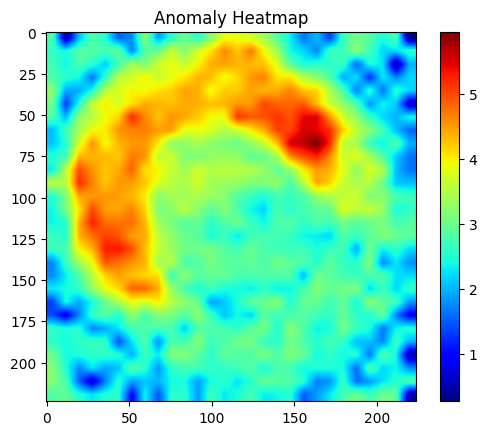

In [ ]:
import matplotlib.pyplot as plt


plt.imshow(heatmaps[0][0].cpu(), cmap = 'jet')
plt.colorbar()
plt.title("Anomaly Heatmap")
plt.show()

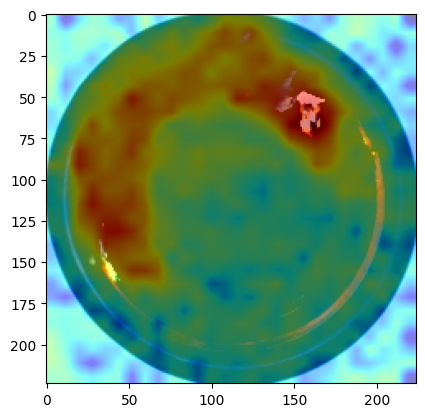

In [ ]:
img = test_dataset[0][0].permute(1,2,0).numpy()

plt.imshow(img)
plt.imshow(heatmaps[0][0].cpu(), cmap="jet", alpha=0.5)
plt.show()

In [ ]:
test_labels = []

for images, labels, masks in test_dataloader:
    test_labels.extend(labels.cpu().numpy())

test_labels = np.array(test_labels)

In [ ]:
test_labels.shape

(83,)

In [ ]:
image_scores.shape

torch.Size([83])

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(test_labels, image_scores.cpu().numpy())

print("AUROC:", auc)

AUROC: 0.9984126984126984


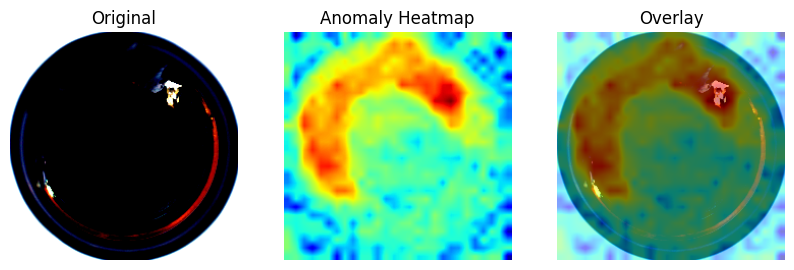

In [ ]:
import matplotlib.pyplot as plt

img, _, _ = test_dataset[0]

img = img.permute(1,2,0).numpy()

heat = heatmaps[0][0].cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Anomaly Heatmap")
plt.imshow(heat, cmap="jet")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(img)
plt.imshow(heat, cmap="jet", alpha=0.5)
plt.axis("off")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

pixel_scores = heatmaps.cpu().numpy().flatten()
pixel_labels = masks.cpu().numpy().flatten()

roc_auc_score(pixel_labels, pixel_scores)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


nan

In [ ]:
# improvements to make: FAISS KNN, multi class, real time deployment

In [ ]:
all_masks = []

with torch.no_grad():
    for images, labels, masks in test_dataloader:

        images = images.to(device)

        feature_maps.clear()
        _ = model(images)

        f2, f3 = feature_maps
        f3 = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)

        f = torch.cat([f2, f3], dim=1)

        B, C, H, W = f.shape
        patches = f.permute(0,2,3,1).reshape(-1, C)

        test_embeddings.append(patches.cpu())

        all_masks.append(masks)

AttributeError: 'Tensor' object has no attribute 'append'